<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [8]:
!pip install "ultralytics>=8.4.0" supervision roboflow

In [9]:
from roboflow import Roboflow

rf = Roboflow(api_key="68mx1ADupbN2O98b0loS")
workspace = rf.workspace("dmitriis-workspace-dlm5q")
project = workspace.project("dogs-pug4x-etars")
version = project.version(1)

dataset = version.download("yolo26")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...
/content/Dogs-1


In [10]:
!yolo task=detect mode=train \
    model=yolo26m.pt \
    data=/content/Dogs-1/data.yaml \
    epochs=15 \
    imgsz=640 \
    plots=True

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dogs-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

In [12]:
from ultralytics import YOLO
import glob

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# любуая картинку из валидационной выборки
img_path = glob.glob("/content/Dogs-1/valid/images/*.jpg")[0]

results = model.predict(source=img_path, conf=0.25, save=True)
print("Saved to:", results[0].save_dir)


image 1/1 /content/Dogs-1/valid/images/real_28_png_jpg.rf.eee7e9a23a5aefc6c48e1c8cf94fe5ef.jpg: 640x640 (no detections), 37.6ms
Speed: 4.9ms preprocess, 37.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Saved to: /content/runs/detect/predict-2


Saving IMG_3855.jpeg to IMG_3855 (5).jpeg

image 1/1 /content/IMG_3855 (5).jpeg: 640x480 1 Dogs, 29.8ms
Speed: 3.1ms preprocess, 29.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)
Найдено объектов: 1
Confidence: [0.19386523962020874]


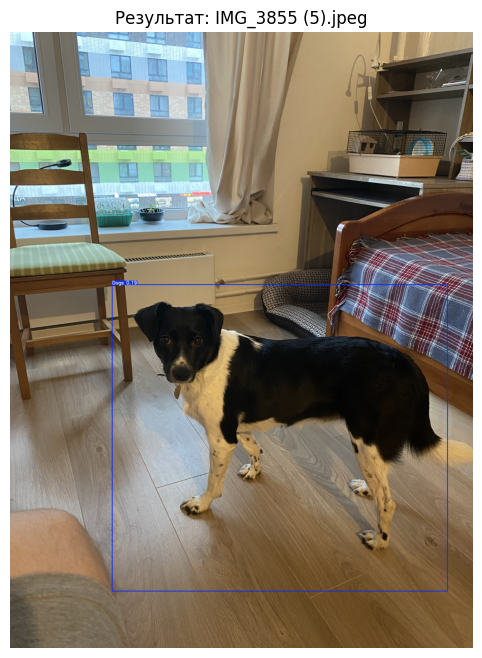

In [20]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

uploaded = files.upload()

for filename in uploaded.keys():
    results = model.predict(
        source=filename,
        conf=0.15,
        save=False
    )

    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        print(f"На изображении {filename} модель ничего не нашла.")
    else:
        print(f"Найдено объектов: {len(boxes)}")
        print("Confidence:", boxes.conf.tolist())

    plotted = results[0].plot(line_width=3, font_size=14)

    plt.figure(figsize=(12, 8))
    plt.imshow(plotted[:, :, ::-1])
    plt.axis("off")
    plt.title(f"Результат: {filename}")
    plt.show()

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [ ]:
# Ваш код

## **Задание 4 (для магистрантов). Обучите модель YOLOv26 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

**Ссылка на датасет в среде roboflow universe:** https://universe.roboflow.com/animals-sqrdn/rsd-god

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [ ]:
# Ваш код